# Step1:ライブラリのインポートとデータ読み込み

In [1]:
from pathlib import Path
from collections import defaultdict
import os
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
FAST_DEBUG = True

N_FOLDS = 3 if FAST_DEBUG else 5
MAX_TRAIN_WELLS = 60 if FAST_DEBUG else None

XGB_PARAMS = {
    "n_estimators": 80 if FAST_DEBUG else 450, # 決定木の数
    "learning_rate": 0.06 if FAST_DEBUG else 0.035, # 学習率
    "max_depth": 5, # 決定木の最大深度
    "min_child_weight": 20, # 決定木の葉の重みの下限
    "subsample": 0.85, # 各決定木のサンプル抽出比
    "colsample_bytree": 0.85, # 説明変数のサンプル抽出比
    "reg_lambda": 4.0,
    "reg_alpha": 0.05,
    "objective": "reg:squarederror", # 二乗誤差回帰で学習
    "eval_metric": "rmse", # 評価指標
    "tree_method": "hist", # 数値を一定の範囲でビニングして処理する
    "max_bin": 256, # 最大のビン数
    "random_state": RANDOM_STATE,
    "n_jobs": -1, # 並列処理数(-1で全コアで処理)
    "device": "cuda",
}

print("FAST_DEBUG:", FAST_DEBUG)
print("N_FOLDS:", N_FOLDS)
print("XGB_PARAMS:", XGB_PARAMS)

FAST_DEBUG: True
N_FOLDS: 3
XGB_PARAMS: {'n_estimators': 80, 'learning_rate': 0.06, 'max_depth': 5, 'min_child_weight': 20, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_lambda': 4.0, 'reg_alpha': 0.05, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'max_bin': 256, 'random_state': 42, 'n_jobs': -1, 'device': 'cuda'}


In [2]:
# データの読み込み
def find_data_root():
    candidates = [
        Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction"),
        Path.cwd(),
    ]
    # 作業ディレクトリからルートディレクトリに至るまでのすべての親ディレクトリをcandidatesに格納
    candidates.extend(Path.cwd().parents)

    # ルートディレクトリを特定して返す
    for root in candidates:
        if (root / "train").is_dir() and (root / "sample_submission.csv").is_file():
            return root.resolve()
        raise FileNotFoundError("Could not find train/ and sample_submission.csv")

DATA_ROOT = find_data_root()
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

DATA_ROOT: /kaggle/input/competitions/rogii-wellbore-geology-prediction
TRAIN_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction/train
TEST_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction/test


In [3]:
# well idごとのデータ読み込み
def well_id_from_path(path):
    # __で区切ったファイル名の最初の区切りを抽出
    return Path(path).name.split("__", 1)[0]

# ディレクトリのすべてのファイル名取得
train_horizontal_paths = sorted(TRAIN_DIR.glob("*__horizontal_well.csv"))
test_horizontal_paths = sorted(TEST_DIR.glob("*__horizontal_well.csv"))

# FAST_DEBUGがTRUEなら最大60件まで
if MAX_TRAIN_WELLS is not None:
    train_horizontal_paths = train_horizontal_paths[:MAX_TRAIN_WELLS]

print(f"Training horizontal wells used: {len(train_horizontal_paths)}")
print(f"Visible test horizontal wells: {len(test_horizontal_paths)}")

sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
sample_sub["well_id"] = sample_sub["id"].str.rsplit("_", n=1).str[0]
sample_sub["row_index"] = sample_sub["id"].str.rsplit("_", n=1).str[1].astype(int)

display(sample_sub.head())
display(sample_sub.groupby("well_id").size().rename("rows_to_predict").reset_index().head())

Training horizontal wells used: 60
Visible test horizontal wells: 3


,id,tvt,well_id,row_index
0,000d7d20_1442,0.0,000d7d20,1442
1,000d7d20_1443,0.0,000d7d20,1443
2,000d7d20_1444,0.0,000d7d20,1444
3,000d7d20_1445,0.0,000d7d20,1445
4,000d7d20_1446,0.0,000d7d20,1446


,well_id,rows_to_predict
0,000d7d20,3836
1,00bbac68,6014
2,00e12e8b,4301


# Step2:特徴量エンジニアリング

In [4]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def robust_slope(x, y, default=0.0):
    """
    データに欠損があっても処理がクラッシュしないようにするロバスト性関数。
    """
    # NumPy配列へ変換、すでにNumPy配列の場合はそのまま
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    # x, y配列内の各要素が有限(infかNaNではない)かどうかを判定。両方Trueの場合のみTrueを返す。
    mask = np.isfinite(x) & np.isfinite(y)
    # x, yともに有限である組み合わせが2つ未満の場合は0を返す。
    if mask.sum() < 2:
        return default
    # 無効な値がある組み合わせを配列から削除する。
    x = x[mask]
    y = y[mask]
    # xの標準偏差が小さすぎる場合は0を返す。
    if np.nanstd(x) < 1e-6:
        return default
    # 最小二乗法で一次式に近似したときの係数を返す。
    return float(np.polyfit(x, y, 1)[0])

def safe_interp(x, xp, fp):
    """
    データに欠損や順序の乱れがあっても、安全に線形補間を行う関数。
    """
    xp = np.asarray(xp, dtype=np.float64)
    fp = np.asarray(fp, dtype=np.float64)
    mask = np.isfinite(xp) & np.isfinite(fp)
    # xp, fpともに有限の組み合わせが2つ未満の場合は、xと同じ形ですべての値がNaNの配列を返す。
    if mask.sum() < 2:
        return np.full_like(np.asarray(x, dtype=np.float64), np.nan, dtype=np.float64)
    # xpが有効な値を昇順で並べ替えたときの、インデックスの配列を返す。
    order = np.argsort(xp[mask])
    # xp, fpそれぞれで有効な値かつ昇順で並べ替えた配列を取得する。
    xp = xp[mask][order]
    fp = fp[mask][order]
    # 線形補間された値を返す。ただし両端よりも外側の場合はNaNを返す。
    return np.interp(np.asarray(x, dtype=np.float64), xp, fp, left=np.nan, right=np.nan)

def load_typewell(well_id, split):
    base = TRAIN_DIR if split == "train" else TEST_DIR
    path = base / f"{well_id}__typewell.csv"
    # pathファイルが存在すれば読み込み、なければ空のデータフレーム作成
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame({"TVT": [], "GR": []})

In [5]:
def build_features_for_well(horizontal_path, split="train", test_row_map=None):
    well_id = well_id_from_path(horizontal_path)
    # pathのcsvファイルを読み込み
    h = pd.read_csv(horizontal_path)
    # well_idのデータフレームを読み込み。なければ空のデータフレーム作成
    tw = load_typewell(well_id, split)

    # hに新たにrow_index列を追加
    h["row_index"] = np.arange(len(h), dtype=np.int64)

    # Target/evaluation rows
    if split == "train":
        # trainデータの場合、TVT_inputがNaNかつTVTがNaNでない行を抽出
        row_mask = h["TVT_input"].isna() & h["TVT"].notna()
        # 行番号のリストを取得
        selected_idx = h.index[row_mask].to_numpy(dtype=np.int64)
    else:
        # テスト用に指定された行マップに含まれていればそれを使う
        if test_row_map is not None and well_id in test_row_map:
            selected_idx = test_row_map[well_id]
        else:
            # なければTVT_inputがNaNの行を使用
            selected_idx = h.index[h["TVT_input"].isna()].to_numpy(dtype=np.int64)

    # 一つもなければ空のデータフレームを返す。
    if len(selected_idx) == 0:
        return pd.DataFrame()

    # TVT_inputが存在するデータをコピー
    known = h[h["TVT_input"].notna()].copy()
    if len(known) == 0:
        # 保守的しきい値なのでコンペデータではほぼ発生しない
        # 既知データが一つもなければTVT_inputをNaNとした1行目のデータをコピーして作成
        known = h.head(1).copy()
        known["TVT_input"] = np.nan

    # TVT_inputが欠損している行を抽出
    first_missing = h.index[h["TVT_input"].isna()]
    # 欠損がある場合はそのインデックスを、ない場合は末尾を取得
    ps_idx = int(first_missing[0]) if len(first_missing) else int(len(h))
    # 既知データの末尾を取得
    last_known = known.iloc[-1]

    # TVT_inputに対するMDの回帰係数を取得
    slope_all = robust_slope(known["MD"], known["TVT_input"])
    # 直近(200行もしくは既知データ数の小さい方)データ
    recent = known.tail(min(200, len(known)))
    # 直近データの回帰係数
    slope_recent = robust_slope(recent["MD"], recent["TVT_input"], default=slope_all)
    # 直近データにおけるTVT_inputとZの回帰係数
    slope_z_recent = robust_slope(recent["Z"], recent["TVT_input"])

    # Current rows
    # 抽出対象のインデックスの指定列データをコピー
    cur = h.loc[selected_idx, ["MD", "X", "Y", "Z", "GR", "row_index"]].copy()
    cur["well_id"] = well_id
    cur["id"] = cur["well_id"] + "_" + cur["row_index"].astype(str)

    # last_knownの指定列のデータを抽出、なければNaNで返す
    ps_md = float(last_known.get("MD", np.nan))
    ps_x = float(last_known.get("X", np.nan))
    ps_y = float(last_known.get("Y", np.nan))
    ps_z = float(last_known.get("Z", np.nan))
    ps_gr = float(last_known.get("GR", np.nan))
    last_known_tvt = float(last_known.get("TVT_input", np.nan))

    cur["n_rows"] = len(h)
    cur["prediction_start_index"] = ps_idx
    cur["last_known_tvt"] = last_known_tvt
    cur["known_tvt_min"] = known["TVT_input"].min()
    cur["known_tvt_max"] = known["TVT_input"].max()
    cur["known_tvt_range"] = known["TVT_input"].max() - known["TVT_input"].min()
    cur["known_tvt_mean"] = known["TVT_input"].mean()
    cur["known_tvt_std"] = known["TVT_input"].std()
    cur["known_gr_mean"] = known["GR"].mean() if "GR" in known else np.nan
    cur["known_gr_std"] = known["GR"].std() if "GR" in known else np.nan
    cur["known_gr_min"] = known["GR"].min() if "GR" in known else np.nan
    cur["known_gr_max"] = known["GR"].max() if "GR" in known else np.nan
    cur["last_known_gr"] = ps_gr
    cur["slope_tvt_md_all"] = slope_all
    cur["slope_tvt_md_recent"] = slope_recent
    cur["slope_tvt_z_recent"] = slope_z_recent

    # 予測開始地点からの相対距離
    cur["row_from_ps"] = cur["row_index"] - ps_idx
    cur["row_frac"] = cur["row_index"] / max(len(h) - 1, 1)
    cur["md_from_ps"] = cur["MD"] - ps_md
    cur["x_from_ps"] = cur["X"] - ps_x
    cur["y_from_ps"] = cur["Y"] - ps_y
    cur["z_from_ps"] = cur["Z"] - ps_z
    cur["xy_dist_from_ps"] = np.sqrt(cur["x_from_ps"] ** 2 + cur["y_from_ps"] ** 2)
    cur["xyz_dist_from_ps"] = np.sqrt(cur["xy_dist_from_ps"] ** 2 + cur["z_from_ps"] ** 2)

    cur["baseline_tvt_all_slope"] = last_known_tvt + slope_all * cur["md_from_ps"]
    cur["baseline_tvt_recent_slope"] = last_known_tvt + slope_recent * cur["md_from_ps"]
    cur["baseline_tvt"] = last_known_tvt

    cur["gr_missing"] = cur["GR"].isna().astype(np.int8)
    # 前後の値を使って線形補間、最初と最後もlimit_direction="both"で補完
    gr_filled = h["GR"].astype(float).interpolate(limit_direction="both")
    # GRの移動平均と移動標準偏差を3つのサイズの窓を使って計算
    # 小さい窓は微小ノイズを反映、大きい窓は地層全体の大きい傾向を反映
    for window in [11, 51, 151]:
        roll = gr_filled.rolling(window=window, center=True, min_periods=max(2, window // 5))
        # 計算した移動平均と移動標準偏差のうち、指定した行のみを抽出
        cur[f"gr_roll_mean_{window}"] = roll.mean().iloc[selected_idx].to_numpy()
        cur[f"gr_roll_std_{window}"] = roll.std().iloc[selected_idx].to_numpy()
    # 1行前、10行前との差分を取る
    cur["gr_diff_1"] = gr_filled.diff(1).iloc[selected_idx].to_numpy()
    cur["gr_diff_10"] = gr_filled.diff(10).iloc[selected_idx].to_numpy()
    cur["gr_minus_last_known"] = cur["GR"] - ps_gr

    if {"TVT", "GR"}.issubset(tw.columns) and len(tw) > 1:
        # TVTとGR列があり、かつ2行以上ある場合
        tw_tvt = tw["TVT"].astype(float)
        tw_gr = tw["GR"].astype(float)
        cur["typewell_tvt_min"] = tw_tvt.min()
        cur["typewell_tvt_max"] = tw_tvt.max()
        cur["typewell_tvt_range"] = tw_tvt.max() - tw_tvt.min()
        cur["typewell_gr_mean"] = tw_gr.mean()
        cur["typewell_gr_std"] = tw_gr.std()
        cur["typewell_gr_min"] = tw_gr.min()
        cur["typewell_gr_max"] = tw_gr.max()
        cur["tw_gr_at_last_known_tvt"] = safe_interp(np.array([last_known_tvt]), tw_tvt, tw_gr)[0]
        cur["tw_gr_at_baseline_tvt"] = safe_interp(cur["baseline_tvt"].to_numpy(), tw_tvt, tw_gr)
        cur["tw_gr_at_baseline_all_slope"] = safe_interp(cur["baseline_tvt_all_slope"].to_numpy(), tw_tvt, tw_gr)
        cur["gr_minus_tw_baseline"] = cur["GR"] - cur["tw_gr_at_baseline_tvt"]
        cur["gr_minus_tw_last_known"] = cur["GR"] -  cur["tw_gr_at_last_known_tvt"]
    else:
        for col in [
            "typewell_tvt_min", "typewell_tvt_max", "typewell_tvt_range",
            "typewell_gr_mean", "typewell_gr_std", "typewell_gr_min", "typewell_gr_max",
            "tw_gr_at_last_known_tvt", "tw_gr_at_baseline_tvt", "tw_gr_at_baseline_all_slope",
            "gr_minus_tw_baseline", "gr_minus_tw_last_known",
        ]:
            # それ以外はすべてNaNで置き換え
            cur[col] = np.nan

    if split == "train":
        cur["target_tvt"] = h.loc[selected_idx, "TVT"].to_numpy()
        cur["target_residual"] = cur["target_tvt"] - cur["baseline_tvt"]

    for col in cur.columns:
        if col not in ["well_id", "id"]:
            cur[col] = pd.to_numeric(cur[col], downcast="float")

    return cur.reset_index(drop=True)


# Step3:訓練データ作成

In [6]:
train_parts = []
for i, path in enumerate(train_horizontal_paths, start=1):
    train_parts.append(build_features_for_well(path, split="train"))
    if i % 100 == 0:
        print(f"Processed {i}/{len(train_horizontal_paths)} train wells")

train_df = pd.concat(train_parts, ignore_index=True)
del train_parts
gc.collect()

print("train_df shape:", train_df.shape)
display(train_df.head())
print("Target rows:", len(train_df))
print("Unique wells:", train_df["well_id"].nunique())

train_df shape: (291931, 59)


,MD,X,Y,Z,GR,row_index,well_id,id,n_rows,prediction_start_index,last_known_tvt,known_tvt_min,known_tvt_max,known_tvt_range,known_tvt_mean,known_tvt_std,known_gr_mean,known_gr_std,known_gr_min,known_gr_max,last_known_gr,slope_tvt_md_all,slope_tvt_md_recent,slope_tvt_z_recent,row_from_ps,row_frac,md_from_ps,x_from_ps,y_from_ps,z_from_ps,xy_dist_from_ps,xyz_dist_from_ps,baseline_tvt_all_slope,baseline_tvt_recent_slope,baseline_tvt,gr_missing,gr_roll_mean_11,gr_roll_std_11,gr_roll_mean_51,gr_roll_std_51,gr_roll_mean_151,gr_roll_std_151,gr_diff_1,gr_diff_10,gr_minus_last_known,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,typewell_gr_min,typewell_gr_max,tw_gr_at_last_known_tvt,tw_gr_at_baseline_tvt,tw_gr_at_baseline_all_slope,gr_minus_tw_baseline,gr_minus_tw_last_known,target_tvt,target_residual
0,12909.0,2983537.06,1070212.72,-9735.070312,NaN,1442.0,000d7d20,000d7d20_1442,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,0.0,0.273261,1.0,-0.03,1.00,0.01,1.000450,1.000500,11747.672852,11747.370117,11747.370117,1,105.311470,0.890245,103.299164,4.825131,98.586723,14.259318,-0.205555,1.473982,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,95.444763,NaN,NaN,11747.379883,0.01
1,12910.0,2983537.03,1070213.72,-9735.059570,NaN,1443.0,000d7d20,000d7d20_1443,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,1.0,0.273451,2.0,-0.06,2.00,0.02,2.000900,2.001000,11747.975586,11747.370117,11747.370117,1,105.036865,0.962581,102.871223,4.878050,98.374031,14.315206,-0.205555,0.591598,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,97.856438,NaN,NaN,11747.389648,0.02
2,12911.0,2983537.00,1070214.72,-9735.049805,NaN,1444.0,000d7d20,000d7d20_1444,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,2.0,0.273640,3.0,-0.09,3.00,0.03,3.001350,3.001500,11748.278320,11747.371094,11747.370117,1,104.757362,1.017637,102.427391,4.973273,98.155296,14.380600,-0.205555,-0.290786,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.770462,NaN,NaN,11747.400391,0.03
3,12912.0,2983536.97,1070215.71,-9735.040039,104.818207,1445.0,000d7d20,000d7d20_1445,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,3.0,0.273830,4.0,-0.12,3.99,0.04,3.991804,3.992004,11748.581055,11747.371094,11747.370117,0,104.472954,1.056209,101.967651,5.109817,97.930534,14.455724,-0.205555,-1.173170,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.563736,11.505805,11.505805,11747.400391,0.03
4,12913.0,2983536.94,1070216.71,-9735.030273,103.960892,1446.0,000d7d20,000d7d20_1446,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,4.0,0.274019,5.0,-0.15,4.99,0.05,4.992254,4.992505,11748.882812,11747.371094,11747.370117,0,104.137505,1.157626,101.492012,5.285673,97.699738,14.540770,-0.857316,-2.707315,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,96.880966,10.648488,10.648488,11747.410156,0.04


Target rows: 291931
Unique wells: 60


In [7]:
exclude_cols = {"well_id", "id", "target_tvt", "target_residual"}
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X = train_df[feature_cols].astype(np.float32)
y_resid = train_df["target_residual"].astype(np.float32)
y_true = train_df["target_tvt"].astype(np.float32)
baseline = train_df["baseline_tvt"].astype(np.float32)
groups = train_df["well_id"].values

print(f"Number of features: {len(feature_cols)}")
print(feature_cols)

Number of features: 55
['MD', 'X', 'Y', 'Z', 'GR', 'row_index', 'n_rows', 'prediction_start_index', 'last_known_tvt', 'known_tvt_min', 'known_tvt_max', 'known_tvt_range', 'known_tvt_mean', 'known_tvt_std', 'known_gr_mean', 'known_gr_std', 'known_gr_min', 'known_gr_max', 'last_known_gr', 'slope_tvt_md_all', 'slope_tvt_md_recent', 'slope_tvt_z_recent', 'row_from_ps', 'row_frac', 'md_from_ps', 'x_from_ps', 'y_from_ps', 'z_from_ps', 'xy_dist_from_ps', 'xyz_dist_from_ps', 'baseline_tvt_all_slope', 'baseline_tvt_recent_slope', 'baseline_tvt', 'gr_missing', 'gr_roll_mean_11', 'gr_roll_std_11', 'gr_roll_mean_51', 'gr_roll_std_51', 'gr_roll_mean_151', 'gr_roll_std_151', 'gr_diff_1', 'gr_diff_10', 'gr_minus_last_known', 'typewell_tvt_min', 'typewell_tvt_max', 'typewell_tvt_range', 'typewell_gr_mean', 'typewell_gr_std', 'typewell_gr_min', 'typewell_gr_max', 'tw_gr_at_last_known_tvt', 'tw_gr_at_baseline_tvt', 'tw_gr_at_baseline_all_slope', 'gr_minus_tw_baseline', 'gr_minus_tw_last_known']


# Step4:バリデーション

In [8]:
# データセットを重複のないグループに分けて複数回バリデーションをする。
# shuffleをTrueにすると各テストフォールドのサンプル数がおなじになる
gkf = GroupKFold(n_splits=N_FOLDS)
oof = np.zeros(len(train_df), dtype=np.float32)
fold_rows = []
models = []

for fold, (trn_idx, val_idx) in enumerate(gkf.split(X, y_resid, groups), start=1):
    print(f"\n==== Fold {fold}/{N_FOLDS} ====")
    print(f"Train rows: {len(trn_idx):,} | Valid rows: {len(val_idx):,}")
    print(f"Train wells: {len(np.unique(groups[trn_idx])):,} | Valid wells: {len(np.unique(groups[val_idx])):,}")

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        X.iloc[trn_idx],
        y_resid.iloc[trn_idx],
        eval_set=[(X.iloc[val_idx], y_resid.iloc[val_idx])],
        verbose=100,
    )

    val_resid_pred = model.predict(X.iloc[val_idx]).astype(np.float32)
    val_pred = baseline.iloc[val_idx].to_numpy() + val_resid_pred
    oof[val_idx] = val_pred

    fold_rmse = rmse(y_true.iloc[val_idx], val_pred)
    baseline_rmse = rmse(y_true.iloc[val_idx], baseline.iloc[val_idx])

    fold_rows.append({
        "fold": fold,
        "valid_rows": len(val_idx),
        "valid_wells": len(np.unique(groups[val_idx])),
        "baseline_rmse": baseline_rmse,
        "xgb_rmse": fold_rmse,
        "improvement": baseline_rmse - fold_rmse,
    })
    models.append(model)

    print(f"Fold {fold} baseline RMSE: {baseline_rmse:.5f}")
    print(f"Fold {fold} XGB RMSE:      {fold_rmse:.5f}")

cv = pd.DataFrame(fold_rows)
display(cv)
print(f"OOF baseline RMSE: {rmse(y_true, baseline):.5f}")
print(f"OOF XGB RMSE:      {rmse(y_true, oof):.5f}")
print(f"Mean fold RMSE:    {cv['xgb_rmse'].mean():.5f} +/- {cv['xgb_rmse'].std():.5f}")


==== Fold 1/3 ====
Train rows: 194,579 | Valid rows: 97,352
Train wells: 40 | Valid wells: 20
[0]	validation_0-rmse:13.35807
[79]	validation_0-rmse:13.63811
Fold 1 baseline RMSE: 13.01505
Fold 1 XGB RMSE:      13.63813

==== Fold 2/3 ====
Train rows: 194,864 | Valid rows: 97,067
Train wells: 40 | Valid wells: 20
[0]	validation_0-rmse:14.94375
[79]	validation_0-rmse:14.82239
Fold 2 baseline RMSE: 14.29855
Fold 2 XGB RMSE:      14.82228

==== Fold 3/3 ====
Train rows: 194,419 | Valid rows: 97,512
Train wells: 40 | Valid wells: 20
[0]	validation_0-rmse:12.04563
[79]	validation_0-rmse:12.73449
Fold 3 baseline RMSE: 11.44414
Fold 3 XGB RMSE:      12.73457


,fold,valid_rows,valid_wells,baseline_rmse,xgb_rmse,improvement
0,1,97352,20,13.015053,13.638127,-0.623074
1,2,97067,20,14.298553,14.822275,-0.523722
2,3,97512,20,11.444143,12.734569,-1.290426


OOF baseline RMSE: 12.96973
OOF XGB RMSE:      13.75662
Mean fold RMSE:    13.73166 +/- 1.04699


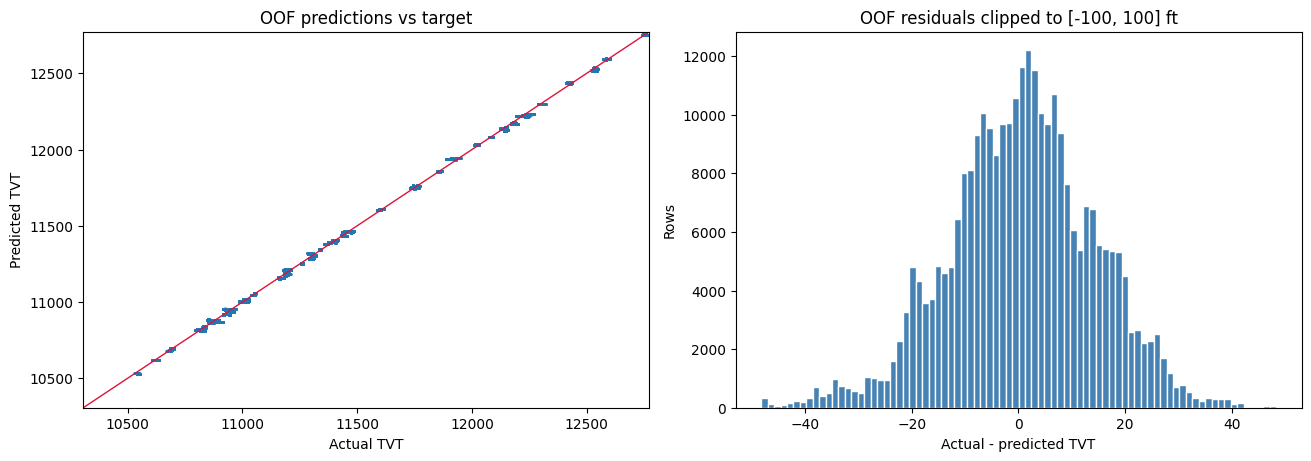

In [10]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axes[0].scatter(y_true, oof, s=1, alpha=0.08)
lo = float(np.nanpercentile(y_true, 1))
hi = float(np.nanpercentile(y_true, 99))
axes[0].plot([lo, hi], [lo, hi], color="crimson", lw=1)
axes[0].set_xlim(lo, hi)
axes[0].set_ylim(lo, hi)
axes[0].set_title("OOF predictions vs target")
axes[0].set_xlabel("Actual TVT")
axes[0].set_ylabel("Predicted TVT")

resid = y_true.to_numpy() - oof
axes[1].hist(np.clip(resid, -100, 100), bins=80, color="steelblue", edgecolor="white")
axes[1].set_title("OOF residuals clipped to [-100, 100] ft")
axes[1].set_xlabel("Actual - predicted TVT")
axes[1].set_ylabel("Rows")
plt.show()

,feature,fold_1,fold_2,fold_3,mean_importance
45,typewell_tvt_range,0.178273,0.036509,0.054120,0.089634
46,typewell_gr_mean,0.148347,0.111637,0.004268,0.088084
20,slope_tvt_md_recent,0.113740,0.073568,0.073502,0.086937
14,known_gr_mean,0.043797,0.067095,0.036290,0.049061
43,typewell_tvt_min,0.000000,0.002425,0.137731,0.046718
6,n_rows,0.010466,0.078454,0.044681,0.044534
51,tw_gr_at_baseline_tvt,0.049894,0.004758,0.069096,0.041250
48,typewell_gr_min,0.005175,0.100034,0.014680,0.039963
50,tw_gr_at_last_known_tvt,0.038894,0.023050,0.044858,0.035601
17,known_gr_max,0.005573,0.031306,0.067840,0.034906


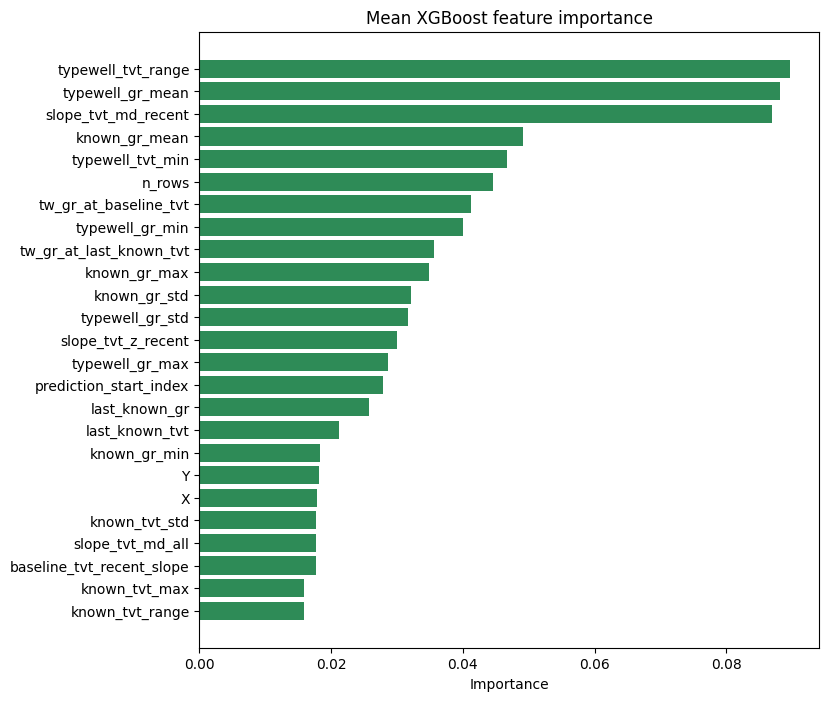

In [11]:
# 特徴量の重要度マッピング
importance = pd.DataFrame({"feature": feature_cols})
for fold, model in enumerate(models, start=1):
    importance[f"fold_{fold}"] = model.feature_importances_
importance["mean_importance"] = importance[[c for c in importance.columns if c.startswith("fold_")]].mean(axis=1)
importance = importance.sort_values("mean_importance", ascending=False)

display(importance.head(25))

fig, ax = plt.subplots(figsize=(8, 8))
top = importance.head(25).sort_values("mean_importance")
ax.barh(top["feature"], top["mean_importance"], color="seagreen")
ax.set_title("Mean XGBoost feature importance")
ax.set_xlabel("Importance")
plt.show()

# Step5:テストデータ作成と予測

In [12]:
test_parts = []
for i, path in enumerate(test_horizontal_paths, start=1):
    test_parts.append(build_features_for_well(path, split="test", test_row_map=None))
    if i % 50 == 0:
        print(f"Processed {i}/{len(test_horizontal_paths)} test wells")

test_df = pd.concat(test_parts, ignore_index=True)
del test_parts
gc.collect()

print("test_df shape:", test_df.shape)
display(test_df.head())

test_df shape: (14151, 57)


,MD,X,Y,Z,GR,row_index,well_id,id,n_rows,prediction_start_index,last_known_tvt,known_tvt_min,known_tvt_max,known_tvt_range,known_tvt_mean,known_tvt_std,known_gr_mean,known_gr_std,known_gr_min,known_gr_max,last_known_gr,slope_tvt_md_all,slope_tvt_md_recent,slope_tvt_z_recent,row_from_ps,row_frac,md_from_ps,x_from_ps,y_from_ps,z_from_ps,xy_dist_from_ps,xyz_dist_from_ps,baseline_tvt_all_slope,baseline_tvt_recent_slope,baseline_tvt,gr_missing,gr_roll_mean_11,gr_roll_std_11,gr_roll_mean_51,gr_roll_std_51,gr_roll_mean_151,gr_roll_std_151,gr_diff_1,gr_diff_10,gr_minus_last_known,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,typewell_gr_min,typewell_gr_max,tw_gr_at_last_known_tvt,tw_gr_at_baseline_tvt,tw_gr_at_baseline_all_slope,gr_minus_tw_baseline,gr_minus_tw_last_known
0,12909.0,2983537.06,1070212.72,-9735.070312,NaN,1442.0,000d7d20,000d7d20_1442,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,0.0,0.273261,1.0,-0.03,1.00,0.01,1.000450,1.000500,11747.672852,11747.370117,11747.370117,1,105.311470,0.890245,103.299164,4.825131,98.586723,14.259318,-0.205555,1.473982,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,95.444763,NaN,NaN
1,12910.0,2983537.03,1070213.72,-9735.059570,NaN,1443.0,000d7d20,000d7d20_1443,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,1.0,0.273451,2.0,-0.06,2.00,0.02,2.000900,2.001000,11747.975586,11747.370117,11747.370117,1,105.036865,0.962581,102.871223,4.878050,98.374031,14.315206,-0.205555,0.591598,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,97.856438,NaN,NaN
2,12911.0,2983537.00,1070214.72,-9735.049805,NaN,1444.0,000d7d20,000d7d20_1444,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,2.0,0.273640,3.0,-0.09,3.00,0.03,3.001350,3.001500,11748.278320,11747.371094,11747.370117,1,104.757362,1.017637,102.427391,4.973273,98.155296,14.380600,-0.205555,-0.290786,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.770462,NaN,NaN
3,12912.0,2983536.97,1070215.71,-9735.040039,104.818207,1445.0,000d7d20,000d7d20_1445,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,3.0,0.273830,4.0,-0.12,3.99,0.04,3.991804,3.992004,11748.581055,11747.371094,11747.370117,0,104.472954,1.056209,101.967651,5.109817,97.930534,14.455724,-0.205555,-1.173170,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.563736,11.505805,11.505805
4,12913.0,2983536.94,1070216.71,-9735.030273,103.960892,1446.0,000d7d20,000d7d20_1446,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,4.0,0.274019,5.0,-0.15,4.99,0.05,4.992254,4.992505,11748.882812,11747.371094,11747.370117,0,104.137505,1.157626,101.492012,5.285673,97.699738,14.540770,-0.857316,-2.707315,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,96.880966,10.648488,10.648488


In [13]:
X_test = test_df[feature_cols].astype(np.float32)
test_baseline = test_df["baseline_tvt"].to_numpy(dtype=np.float32)

test_resid_pred = np.zeros(len(test_df), dtype=np.float32)
for fold, model in enumerate(models, start=1):
    pred = model.predict(X_test).astype(np.float32)
    test_resid_pred += pred / len(models)
    print(f"Predicted test with fold model {fold}")

test_df["tvt"] = test_baseline + test_resid_pred

display(test_df[["id", "baseline_tvt", "tvt"]].head())
print(test_df["tvt"].describe())

Predicted test with fold model 1
Predicted test with fold model 2
Predicted test with fold model 3


,id,baseline_tvt,tvt
0,000d7d20_1442,11747.370117,11747.285156
1,000d7d20_1443,11747.370117,11747.285156
2,000d7d20_1444,11747.370117,11747.285156
3,000d7d20_1445,11747.370117,11747.285156
4,000d7d20_1446,11747.370117,11747.286133


count    14151.000000
mean     11905.082031
std        277.007263
min      11599.289062
25%      11610.130859
50%      11747.173828
75%      12224.745117
max      12229.330078
Name: tvt, dtype: float64


# Step6:提出ファイルの作成

In [14]:
submission = test_df[["id", "tvt"]].copy()
submission["tvt"] = pd.to_numeric(submission["tvt"], errors="coerce")
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(submission.shape)
display(submission.head())

Saved submission.csv
(14151, 2)


,id,tvt
0,000d7d20_1442,11747.285156
1,000d7d20_1443,11747.285156
2,000d7d20_1444,11747.285156
3,000d7d20_1445,11747.285156
4,000d7d20_1446,11747.286133
